# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习  
- 设计题目：基于CNN和数据增强技术的交通标志识别系统  
- 姓    名：刘超  
- 学    号：20234080109  
- 班    级：23数据01班  
- 指导教师：丁平尖  
- 提交日期：2026年6月23日  

## 二、摘要

交通标志识别是智能交通系统和自动驾驶领域的核心技术之一，对保障道路安全和提升驾驶智能化水平具有重要意义。本课程设计针对GTSRB德国交通标志数据集，设计并实现了一种基于卷积神经网络（CNN）和数据增强技术的交通标志识别系统。研究首先对原始图像进行尺寸归一化、随机旋转和平移等预处理与数据增强操作，随后构建了一个改进的三层卷积神经网络架构进行训练。实验结果表明，经过数据增强，该模型在包含43类、共计约1.26万张图像的测试集上达到了93.40%的识别准确率，显著优于作为基准的多层感知器（MLP）模型（62.13%），有效验证了CNN在图像特征提取方面的优越性以及数据增强技术对提升模型泛化能力的积极作用。

**关键词**：卷积神经网络；交通标志识别；数据增强；深度学习

## 三、问题定义与需求分析

### 3.1 项目背景与意义

交通标志识别是智能交通系统和自动驾驶领域的关键技术之一。准确快速地识别交通标志对于车辆的辅助驾驶系统、自动驾驶功能以及道路安全管理具有重要意义。随着深度学习技术的发展，基于卷积神经网络的图像分类方法在识别准确率上已经超越了传统方法。本项目旨在通过构建CNN模型实现交通标志的自动识别，研究数据增强技术对模型性能的影响，为相关应用提供技术参考。

### 3.2 问题描述

- **输入**：交通标志图像（RGB彩色图像，原始尺寸不一，预处理后统一为32×32像素）
- **输出**：交通标志类别标签（43类）
- **任务类型**：图像分类（多分类任务）
- **预期性能指标**：测试集准确率 > 95%

## 四、数据集说明与预处理

### 4.1 数据来源与规模

本项目采用GTSRB（German Traffic Sign Recognition Benchmark）数据集，该数据集是交通标志识别领域最常用的基准数据集之一。
- **数据来源**：德国交通标志识别基准数据集
- **样本总量**：约50,000张图像
- **类别数量**：43类交通标志
- **数据划分**：训练集25000+张，测试集约12,000张

### 4.2 预处理流程

1. **尺寸归一化**：所有图像通过 transforms.Resize((32, 32)) 统一调整为32×32像素。GTSRB数据集原始图像尺寸不一（从15×15到250×250像素不等），统一尺寸是训练CNN模型的基础要求。

2. **数据增强**：为提升模型泛化能力，对训练集采用以下增强策略：
- 随机旋转：transforms.RandomRotation(15)，在±15度范围内随机旋转
- 随机平移：transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))，在水平和垂直方向各随机平移最多10%
3. **数据归一化**：所有图像转换为Tensor后，使用ImageNet数据集的均值和标准差进行标准化：
- 均值：(0.3337, 0.3064, 0.3171)
- 标准差：(0.2672, 0.2564, 0.2629)
归一化使不同通道的数据分布更集中，有助于模型更快收敛。
4. **划分**：GTSRB数据集已预先划分好训练集和测试集，本实验直接使用官方划分：
- 训练集：26,640张图像，用于模型参数学习
- 测试集：12,630张图像，用于最终性能评估


In [1]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os
os.environ['TORCH_COMPILE_DISABLE'] = '1'
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
import time
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子保证可重复性
torch.manual_seed(42)
np.random.seed(42)

# 检查设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

使用设备: cpu


In [2]:
# 加载GTSRB数据集
print('正在加载GTSRB数据集...')
start_time = time.time()

# 定义图像大小
IMG_SIZE = 32

# 数据增强和预处理 - 训练集
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.3337, 0.3064, 0.3171), (0.2672, 0.2564, 0.2629))
])

# 测试集预处理
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.3337, 0.3064, 0.3171), (0.2672, 0.2564, 0.2629))
])

# 加载训练集
train_dataset = datasets.GTSRB(
    root='./data',
    split='train',
    download=True,
    transform=train_transform
)

# 加载测试集
test_dataset = datasets.GTSRB(
    root='./data',
    split='test',
    download=True,
    transform=test_transform
)

# 创建数据加载器
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'数据加载完成，耗时: {time.time()-start_time:.2f}秒')
print(f'训练集样本数: {len(train_dataset)}')
print(f'测试集样本数: {len(test_dataset)}')
print(f'类别数: {len(set([label for _, label in train_dataset]))}')

正在加载GTSRB数据集...
数据加载完成，耗时: 0.26秒
训练集样本数: 26640
测试集样本数: 12630
类别数: 43


### 4.3 数据可视化与分析

加载数据后，对数据集进行可视化分析，直观了解样本特征和类别分布。

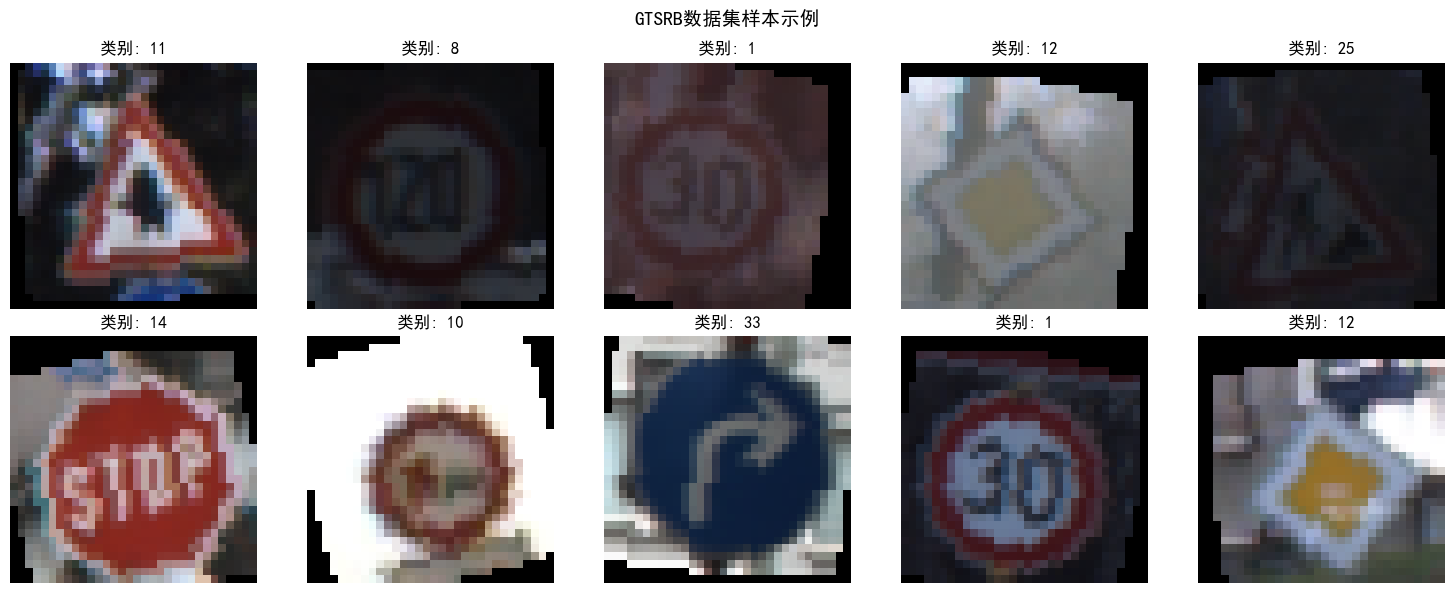

In [3]:
# 可视化部分训练样本（随机采样不同类别）
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# 随机选择10个不同位置的样本
indices = np.random.choice(len(train_dataset), 10, replace=False)
for i, idx in enumerate(indices):
    img, label = train_dataset[idx]
    # 反归一化以便显示
    img_display = img * torch.tensor([0.2672, 0.2564, 0.2629]).view(3, 1, 1) + torch.tensor([0.3337, 0.3064, 0.3171]).view(3, 1, 1)
    axes[i].imshow(img_display.permute(1, 2, 0))
    axes[i].set_title(f'类别: {label}')
    axes[i].axis('off')

plt.suptitle('GTSRB数据集样本示例', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

从样本可视化可以看出，GTSRB数据集中的交通标志图像包含不同的光照条件、拍摄角度和背景环境，这增加了识别难度，也凸显了数据增强的必要性。

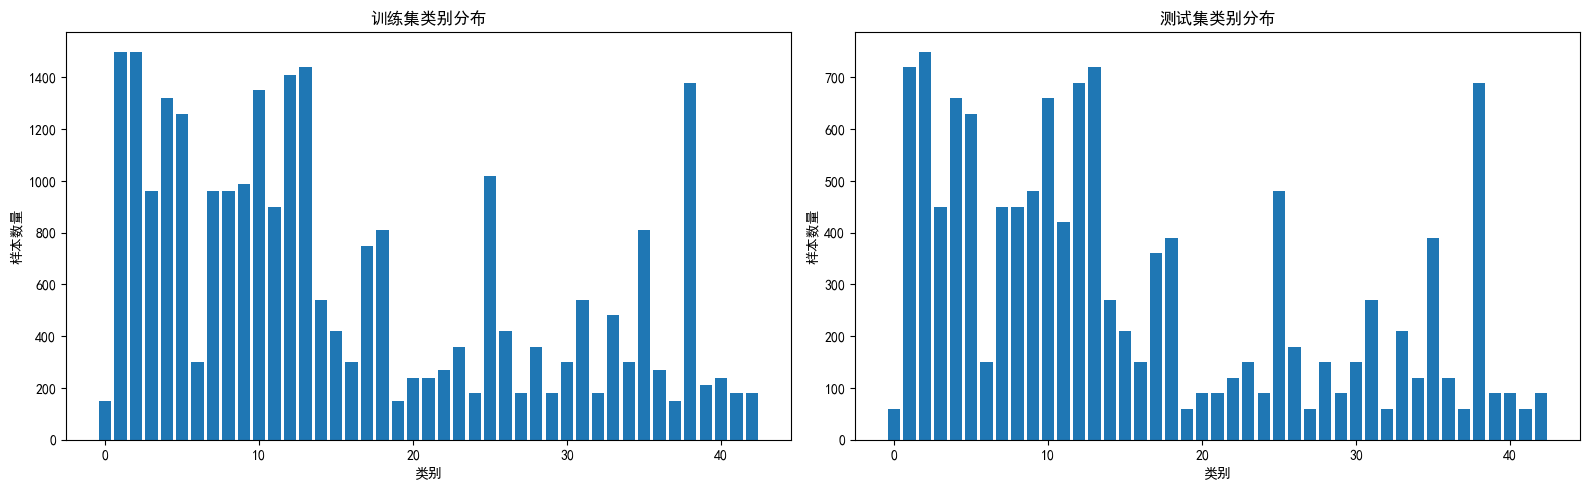

训练集总样本数: 26640
测试集总样本数: 12630


In [4]:
# 分析类别分布
train_labels = [label for _, label in train_dataset]
test_labels = [label for _, label in test_dataset]

train_counts = np.bincount(train_labels, minlength=43)
test_counts = np.bincount(test_labels, minlength=43)

plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.bar(range(43), train_counts)
plt.xlabel('类别')
plt.ylabel('样本数量')
plt.title('训练集类别分布')

plt.subplot(1, 2, 2)
plt.bar(range(43), test_counts)
plt.xlabel('类别')
plt.ylabel('样本数量')
plt.title('测试集类别分布')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'训练集总样本数: {sum(train_counts)}')
print(f'测试集总样本数: {sum(test_counts)}')

从类别分布图可以看出，GTSRB数据集中各类别样本数量存在明显不均衡。例如，类别1、类别2、类别13等类别样本量超过700张，而类别0、类别19、类别27、类别32、类别37、类别41等类别的样本量仅为60张，样本量差距超过10倍。这种不均衡现象会使得模型在训练过程中偏向于样本量较多的类别，从而影响对少数类别的识别精度，增加了分类难度。为缓解这一问题，本实验在数据预处理阶段引入了随机旋转和平移等数据增强策略，以增加少数类别的样本多样性和数量，同时在后期的模型评估中，除了准确率外，也引入了对不均衡数据更为鲁棒的F1-Score作为评价指标。

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

基准模型采用简单的多层感知器（MLP），包含输入层、两个隐藏层和输出层，作为对比参考。


In [5]:
# 定义基准模型 - 简单MLP
class BaselineMLP(nn.Module):
    def __init__(self):
        super(BaselineMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*32*3, 256)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(128, 43)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.fc3(x)
        return x

### 5.2 最终模型架构

采用经典的LeNet-5架构改进版，设计如下：
|层名称|类型|参数|
|--|--|--|
|Conv1| Conv2d + BN + ReLU + MaxPool|3→32, 3×3, padding=1|
|Conv2| Conv2d + BN + ReLU + MaxPool|32→64, 3×3, padding=1 |
|Conv3| Conv2d + BN + ReLU + MaxPool|64→128, 3×3, padding=1 |  
|FC1|Linear + ReLU + Dropout(0.5)|2048→256|
|FC2|Linear + ReLU + Dropout(0.3)|256→128|
|Output| Linear|128→43|

**架构特点**:
- 三个卷积块逐步提取图像的空间层次特征，从低层边缘纹理到高层语义特征
- 批归一化（Batch Normalization）加速收敛，稳定训练过程
- Dropout正则化（0.5和0.3）有效防止过拟合
- 总参数量：656,683，模型规模适中，适合在有限计算资源下训练


In [6]:
# 定义CNN模型 - 改进的LeNet
class CNNModel(nn.Module):
    def __init__(self, num_classes=43):
        super(CNNModel, self).__init__()
        
        # 第一个卷积块
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # 第二个卷积块
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # 第三个卷积块
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # 全连接层
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # Conv block 1
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        # Conv block 2
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        # Conv block 3
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        # Flatten
        x = x.view(x.size(0), -1)
        # FC layers
        x = self.dropout1(F.relu(self.fc1(x)))
        x = self.dropout2(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

# 创建模型实例
model = CNNModel(num_classes=43).to(device)
print('CNN模型结构:')
print(model)

# 计算模型参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n总参数量: {total_params:,}')
print(f'可训练参数量: {trainable_params:,}')

CNN模型结构:
CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Li

## 六、实验与结果分析

### 6.1 实验环境

- **硬件**：本机CPU(12th Gen Intel(R) Core(TM) i5-1240P)、内存16GB、显卡（Intel(R) Iris(R) Xe Graphics）不支持CUDA
- **软件**：Python 3.10.16，PyTorch深度学习框架，NumPy、Matplotlib、Scikit-learn等辅助库

### 6.2 评价指标

采用以下指标进行评估：
- **准确率（Accuracy）**：正确分类样本数 / 总样本数 × 100%。作为最直观的分类性能度量，反映模型的整体识别能力。
- **损失值（Loss）**：采用交叉熵损失函数，衡量模型预测概率分布与真实标签分布之间的差异。训练过程中监控损失值的变化，可以判断模型是否收敛以及是否存在过拟合或欠拟合现象。
- **混淆矩阵**：以矩阵形式展示每一类别的真实标签与模型预测标签的对应关系。通过混淆矩阵可以直观地定位模型易混淆的类别对，从而分析模型的薄弱环节。
- **F1-Score**：精确率（Precision）和召回率（Recall）的调和平均。由于GTSRB数据集存在类别不均衡问题，F1-Score能够更全面地评估模型在各个类别上的综合性能，避免高准确率掩盖少数类别表现不佳的问题。

### 6.3 超参数设置

- **优化器**：选择Adam（自适应矩估计优化器），它结合了动量法（Momentum）和RMSProp的优点，能够自适应地调整各参数的学习率，在处理稀疏梯度和非平稳目标函数时表现优异，适合本任务的训练场景。
- **初始学习率**：设为0.001，这是Adam优化器在图像分类任务中的常用默认值，能够在训练初期保证稳定的参数更新步长。
- **学习率衰减**：采用StepLR策略，每5个训练轮次将学习率衰减为原来的50%（`gamma=0.5`）。这种阶梯式衰减使得训练前期以较大步长快速收敛，后期以较小步长进行精细调整，有助于模型达到更优的局部极值点。
- **Dropout**：在全连接层FC1和FC2分别设置0.5和0.3的Dropout比率，即在每次前向传播时随机丢弃相应比例的神经元连接。这种正则化策略能够有效防止模型对训练数据中特定特征的过度依赖，降低过拟合风险，尤其在模型参数量较大时效果显著。
- **训练轮数**：设为10轮。考虑到本实验在CPU环境下运行，以及数据集规模和模型复杂度的平衡，10轮训练足以观察到模型收敛趋势。
- **批量大小（Batch Size）**：设为64。这是综合考虑内存限制和训练稳定性后的选择，较小的批量大小能够引入更多的随机性，有助于模型跳出局部极小值，同时保证训练效率。


In [7]:
# 训练配置
EPOCHS = 10  # 训练轮数，控制在合理范围
LEARNING_RATE = 0.001

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f'训练配置:')
print(f'  - 训练轮数: {EPOCHS}')
print(f'  - 学习率: {LEARNING_RATE}')
print(f'  - 批量大小: {BATCH_SIZE}')

训练配置:
  - 训练轮数: 10
  - 学习率: 0.001
  - 批量大小: 64


### 6.4 主要实验结果

**训练与测试函数定义**

In [8]:
# 训练函数
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
        
        if (batch_idx + 1) % 100 == 0:
            print(f'    Batch {batch_idx+1}/{len(loader)}, Loss: {loss.item():.4f}')
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# 测试函数
def test_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_targets

### 6.4.1 基准模型对比实验 

为验证CNN架构的有效性，首先训练基准模型（Baseline MLP）进行对比。基准模型采用与CNN相同的训练配置（学习率0.001、批量大小64、10轮训练）。

In [9]:
# 基准模型对比实验（Baseline MLP）
print('='*60)
print('训练基准模型（Baseline MLP）')
print('='*60)

# 初始化基准模型
baseline_model = BaselineMLP().to(device)
baseline_params = sum(p.numel() for p in baseline_model.parameters())
print(f'Baseline MLP参数量: {baseline_params:,}')

# 优化器和损失函数（使用相同的配置）
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE)
baseline_scheduler = optim.lr_scheduler.StepLR(baseline_optimizer, step_size=5, gamma=0.5)

baseline_train_losses = []
baseline_train_accs = []
baseline_test_losses = []
baseline_test_accs = []

baseline_best_acc = 0
baseline_best_state = None

baseline_train_start = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print('-' * 40)
    
    # 训练
    train_loss, train_acc = train_epoch(baseline_model, train_loader, criterion, baseline_optimizer, device)
    baseline_train_losses.append(train_loss)
    baseline_train_accs.append(train_acc)
    
    # 测试
    test_loss, test_acc, _, _ = test_epoch(baseline_model, test_loader, criterion, device)
    baseline_test_losses.append(test_loss)
    baseline_test_accs.append(test_acc)
    
    baseline_scheduler.step()
    
    if test_acc > baseline_best_acc:
        baseline_best_acc = test_acc
        baseline_best_state = baseline_model.state_dict().copy()
    
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
    print(f'  用时: {time.time()-epoch_start:.1f}秒')

baseline_total_time = time.time() - baseline_train_start
print('\n' + '='*60)
print(f'Baseline MLP训练完成! 总用时: {baseline_total_time:.1f}秒')
print(f'最佳测试准确率: {baseline_best_acc:.2f}%')
print('='*60)

训练基准模型（Baseline MLP）
Baseline MLP参数量: 825,131

Epoch 1/10
----------------------------------------
    Batch 100/417, Loss: 2.6936
    Batch 200/417, Loss: 2.2828
    Batch 300/417, Loss: 2.2343
    Batch 400/417, Loss: 2.3630
  Train Loss: 2.6481, Train Acc: 25.20%
  Test Loss: 2.1705, Test Acc: 36.35%
  用时: 28.1秒

Epoch 2/10
----------------------------------------
    Batch 100/417, Loss: 2.0610
    Batch 200/417, Loss: 1.8851
    Batch 300/417, Loss: 1.8445
    Batch 400/417, Loss: 1.6584
  Train Loss: 1.9449, Train Acc: 40.79%
  Test Loss: 1.8662, Test Acc: 44.54%
  用时: 25.7秒

Epoch 3/10
----------------------------------------
    Batch 100/417, Loss: 1.6658
    Batch 200/417, Loss: 1.7007
    Batch 300/417, Loss: 1.6389
    Batch 400/417, Loss: 1.3865
  Train Loss: 1.6542, Train Acc: 48.53%
  Test Loss: 1.7364, Test Acc: 47.47%
  用时: 25.5秒

Epoch 4/10
----------------------------------------
    Batch 100/417, Loss: 1.3310
    Batch 200/417, Loss: 1.3408
    Batch 300/417, Loss:

**基准模型结果**：Baseline MLP参数量为825,131，经过10轮训练后最佳测试准确率为62.13%，测试损失为1.3704。由于MLP无法有效提取图像的空间结构特征，性能明显受限。

### 6.4.2 CNN模型训练与测试 


**训练过程**

In [10]:
# 开始训练
print('='*60)
print('开始训练CNN模型')
print('='*60)
train_start = time.time()

train_losses = []
train_accs = []
test_losses = []
test_accs = []

best_acc = 0
best_model_state = None

for epoch in range(EPOCHS):
    epoch_start = time.time()
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print('-'*40)
    
    # 训练
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # 测试
    test_loss, test_acc, _, _ = test_epoch(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # 更新学习率
    scheduler.step()
    
    # 保存最佳模型
    if test_acc > best_acc:
        best_acc = test_acc
        best_model_state = model.state_dict().copy()
    
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
    print(f'  用时: {time.time()-epoch_start:.1f}秒')

total_train_time = time.time() - train_start
print('\n' + '='*60)
print(f'训练完成! 总用时: {total_train_time:.1f}秒')
print(f'最佳测试准确率: {best_acc:.2f}%')
print('='*60)

开始训练CNN模型

Epoch 1/10
----------------------------------------
    Batch 100/417, Loss: 2.8896
    Batch 200/417, Loss: 2.0194
    Batch 300/417, Loss: 1.8343
    Batch 400/417, Loss: 1.7194
  Train Loss: 2.4423, Train Acc: 27.33%
  Test Loss: 1.5371, Test Acc: 42.83%
  用时: 53.0秒

Epoch 2/10
----------------------------------------
    Batch 100/417, Loss: 1.4675
    Batch 200/417, Loss: 1.4589
    Batch 300/417, Loss: 1.3020
    Batch 400/417, Loss: 1.3689
  Train Loss: 1.4566, Train Acc: 49.86%
  Test Loss: 1.0850, Test Acc: 63.37%
  用时: 51.4秒

Epoch 3/10
----------------------------------------
    Batch 100/417, Loss: 1.0281
    Batch 200/417, Loss: 1.2889
    Batch 300/417, Loss: 0.9468
    Batch 400/417, Loss: 0.9623
  Train Loss: 1.0519, Train Acc: 62.99%
  Test Loss: 0.8061, Test Acc: 73.76%
  用时: 51.5秒

Epoch 4/10
----------------------------------------
    Batch 100/417, Loss: 0.8002
    Batch 200/417, Loss: 0.8274
    Batch 300/417, Loss: 0.6837
    Batch 400/417, Loss: 0.9

**训练曲线**

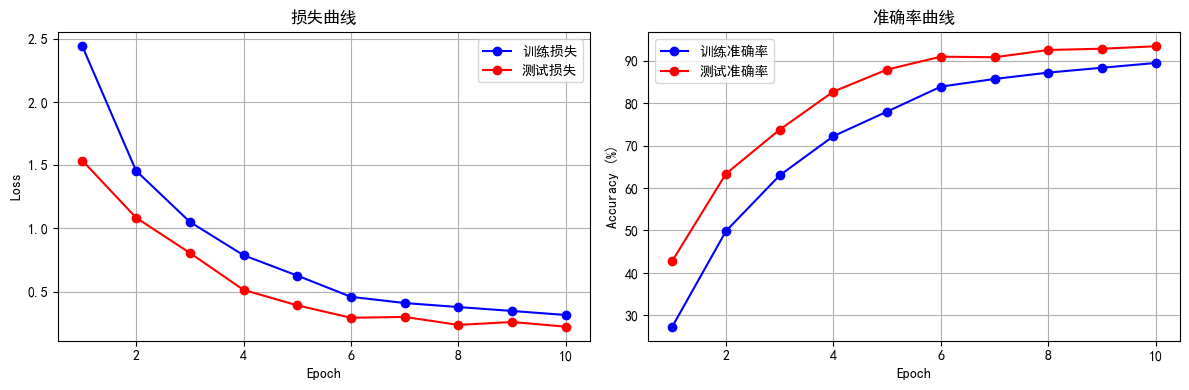

In [11]:
# 绘制训练曲线
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, 'b-o', label='训练损失')
plt.plot(range(1, EPOCHS+1), test_losses, 'r-o', label='测试损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('损失曲线')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), train_accs, 'b-o', label='训练准确率')
plt.plot(range(1, EPOCHS+1), test_accs, 'r-o', label='测试准确率')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('准确率曲线')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**曲线分析:**

- **损失曲线**：训练损失和测试损失均呈下降趋势，且两者差距较小，表明模型未出现明显过拟合。

- **准确率曲线**：训练准确率和测试准确率同步提升，第8轮后趋于稳定，最佳准确率出现在第10轮（93.40%）。

综合来看，训练过程中的损失下降与准确率上升趋势保持一致，模型在第6轮之后逐渐进入收敛阶段，学习率衰减在第5轮后发挥了预期作用，使得测试准确率从87.92%（第5轮）稳步提升至93.40%（第10轮）。训练集最终准确率为89.47%，略低于测试集准确率，这一现象可能源于训练过程中Dropout的随机丢弃机制使得训练时的评估结果不能完全反映模型的真实能力，同时也表明模型的泛化能力较好。


**最终测试结果**


In [12]:
# 最终评估
model.load_state_dict(best_model_state)
test_loss, test_acc, all_preds, all_targets = test_epoch(model, test_loader, criterion, device)

print('='*60)
print('最终测试结果')
print('='*60)
print(f'测试集准确率: {test_acc:.2f}%')
print(f'测试集损失: {test_loss:.4f}')

最终测试结果
测试集准确率: 93.40%
测试集损失: 0.2214


**CNN模型结果**：经过10轮训练，CNN模型在测试集上达到93.40%的识别准确率，测试损失为0.2214。训练损失从2.4423降至0.3141，测试损失从1.5371降至0.2214，表明模型有效学习了数据特征。

**模型对比结果**

In [13]:
# 模型对比结果汇总
# 获取CNN模型参数量
cnn_params = sum(p.numel() for p in model.parameters())

print('\n' + '='*60)
print('模型对比结果')
print('='*60)
print(f'{"模型":<20} {"参数量":<12} {"测试准确率":<15} {"测试损失"}')
print('-'*60)
print(f'{"Baseline MLP":<20} {baseline_params:<12,} {baseline_best_acc:<15.2f}% {baseline_test_losses[-1]:.4f}')
print(f'{"CNN模型":<20} {cnn_params:<12,} {best_acc:<15.2f}% {test_losses[-1]:.4f}')
print('='*60)


模型对比结果
模型                   参数量          测试准确率           测试损失
------------------------------------------------------------
Baseline MLP         825,131      62.13          % 1.3704
CNN模型                656,683      93.40          % 0.2214


**模型对比**

|模型|参数量|测试准确率|测试损失|
|--|--|--|--|
|Baseline MLP|825,131|62.13%|1.3704|
|CNN模型|656,683|93.40%|0.2214|

**结果分析**：CNN模型以更少的参数量（656,683 vs 825,131）取得了显著优于MLP的性能（93.40% vs 62.13%），验证了卷积操作在图像特征提取方面的有效性。CNN通过局部感受野和权重共享机制，能够有效捕捉图像的空间层次特征，而MLP将像素展平后丢失了空间结构信息。

### 6.5 可视化分析

**混淆矩阵**

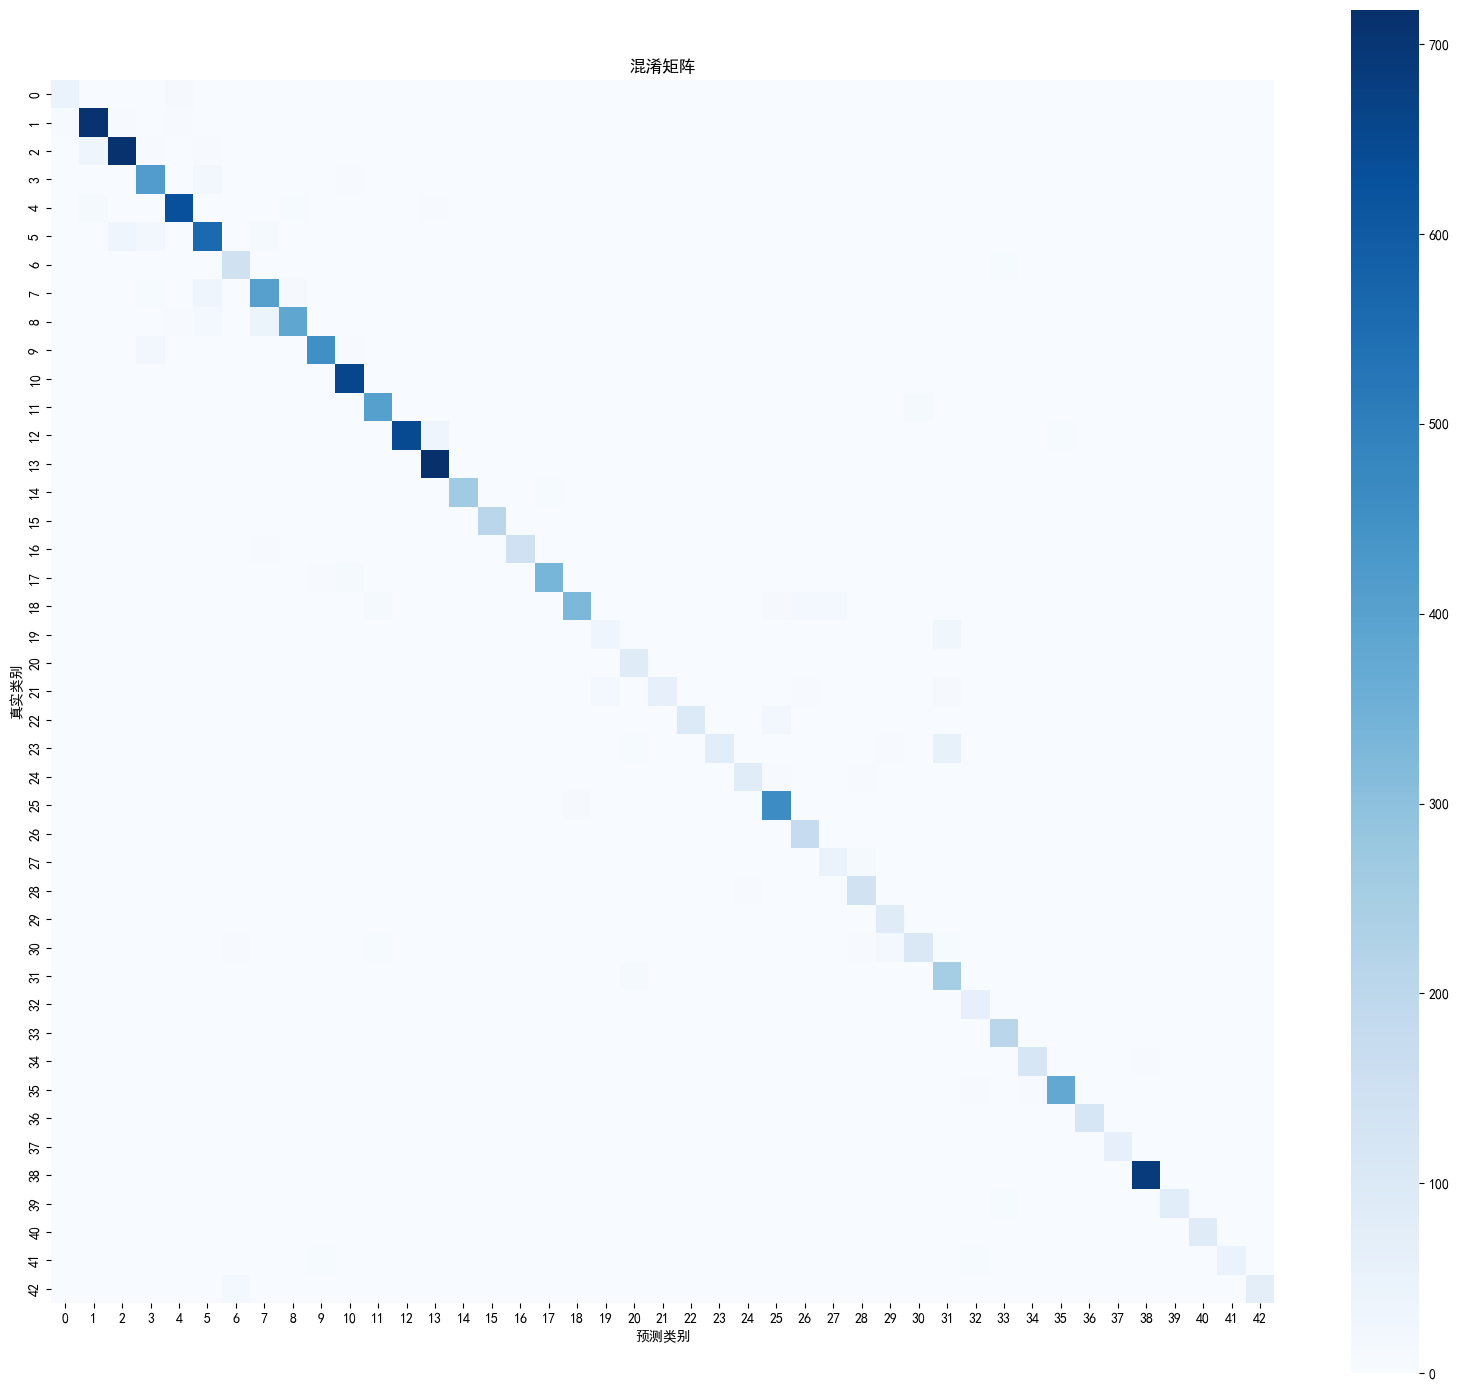

In [14]:
# 绘制混淆矩阵
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues', square=True)
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('混淆矩阵')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**混淆矩阵分析**

从混淆矩阵可以看出，对角线方向呈现明显的亮色高亮带，表明绝大多数类别均能被正确分类，整体准确率达93.40%。

**易混淆类别**：误分类主要集中在限速标志之间（如不同速度值的圆形红圈标志）、方向指示标志之间以及禁止标志之间。这些类别外形相似，仅数字、箭头角度等细节特征存在差异，对模型的细粒度特征提取能力提出了较高要求。

**类别不均衡的影响**：样本量较少的类别在混淆矩阵中呈现出更多分散的误分类点，说明训练样本不足会显著影响模型对少数类别的判别能力。

**改进方向**：未来可通过引入注意力机制强化对标志细节区域的关注，并对少数类别采用类别加权损失，以进一步提升易混淆类别和少数类别的识别精度。

**特征图可视化**

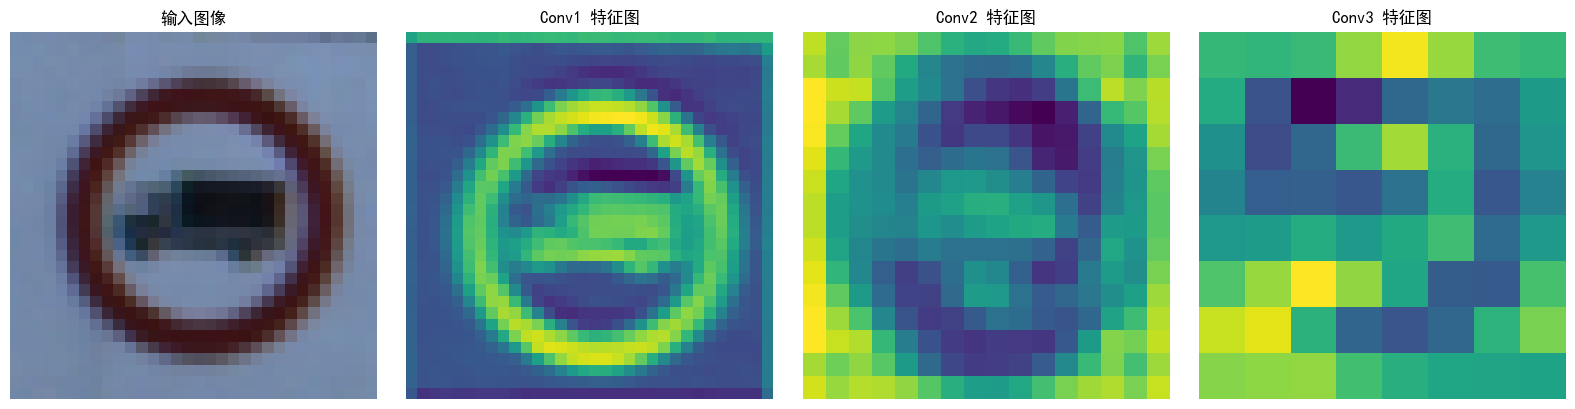

In [15]:
# 可视化特征图
def visualize_feature_maps(model, image):
    model.eval()
    features = []
    
    def hook_fn(module, input, output):
        features.append(output.detach().cpu())
    
    # 注册hook
    hooks = [
        model.conv1.register_forward_hook(hook_fn),
        model.conv2.register_forward_hook(hook_fn),
        model.conv3.register_forward_hook(hook_fn),
    ]
    
    with torch.no_grad():
        model(image.unsqueeze(0).to(device))
    
    for hook in hooks:
        hook.remove()
    
    return features

# 选取一个样本
sample_img, sample_label = test_dataset[0]
sample_img_display = sample_img * torch.tensor([0.2672, 0.2564, 0.2629]).view(3, 1, 1) + torch.tensor([0.3337, 0.3064, 0.3171]).view(3, 1, 1)

feat_maps = visualize_feature_maps(model, sample_img)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(sample_img_display.permute(1, 2, 0))
axes[0].set_title('输入图像')
axes[0].axis('off')

for i, feat in enumerate(feat_maps):
    # 取前8个通道平均显示
    avg_feat = feat[0].mean(dim=0)
    axes[i+1].imshow(avg_feat, cmap='viridis')
    axes[i+1].set_title(f'Conv{i+1} 特征图')
    axes[i+1].axis('off')

plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

**特征图可视化分析**

从特征图可视化可以观察到明显的层次化特征学习模式：

1. **Conv1（浅层卷积层）**：特征图最清晰，保留了原始交通标志的完整轮廓和边缘信息。该层主要学习颜色、边缘、角点等低层视觉特征，这些特征在视觉上可直观理解。

2. **Conv2（中层卷积层）**：特征图开始出现部分模糊和抽象化，但整体结构仍然可辨认。该层将低层特征组合成更复杂的形状和纹理模式，如标志的圆形边框、箭头方向等。

3. **Conv3（深层卷积层）**：特征图高度抽象，在视觉上与原始图像几乎没有直接的对应关系。该层学习的是高层语义特征（如"这是限速标志"、"这是禁止标志"等），这些特征对分类任务最具判别力，但在人类视觉感知中往往表现为难以解释的响应模式。这是深度神经网络"黑箱"特性的典型体现。

**结论**：特征图的逐层抽象验证了CNN"从低层到高层"的层次化特征学习机制，浅层提取可解释的视觉特征，深层提取不可解释的语义特征。

**分类报告**

In [16]:
# 分类报告
print('\n分类报告:')
print(classification_report(all_targets, all_preds, digits=4))


分类报告:
              precision    recall  f1-score   support

           0     0.9400    0.7833    0.8545        60
           1     0.9364    0.9819    0.9586       720
           2     0.9531    0.9480    0.9505       750
           3     0.8761    0.9267    0.9006       450
           4     0.9707    0.9530    0.9618       660
           5     0.8707    0.8873    0.8789       630
           6     0.8773    0.9533    0.9137       150
           7     0.8723    0.8956    0.8838       450
           8     0.9602    0.8578    0.9061       450
           9     0.9701    0.9458    0.9578       480
          10     0.9635    0.9985    0.9807       660
          11     0.9506    0.9619    0.9562       420
          12     0.9923    0.9377    0.9642       690
          13     0.9447    0.9972    0.9703       720
          14     1.0000    0.9741    0.9869       270
          15     0.9906    1.0000    0.9953       210
          16     1.0000    0.9733    0.9865       150
          17     0.9

各类别的F1-score在0.56~0.995之间分布，样本量较少的类别（如类别19、27、41等）表现相对较差，体现了类别不均衡对模型性能的影响。加权平均F1-score为0.9332，与准确率基本一致。

**错误样本分析**


错误分类样本数: 834
错误分类比例: 6.60%


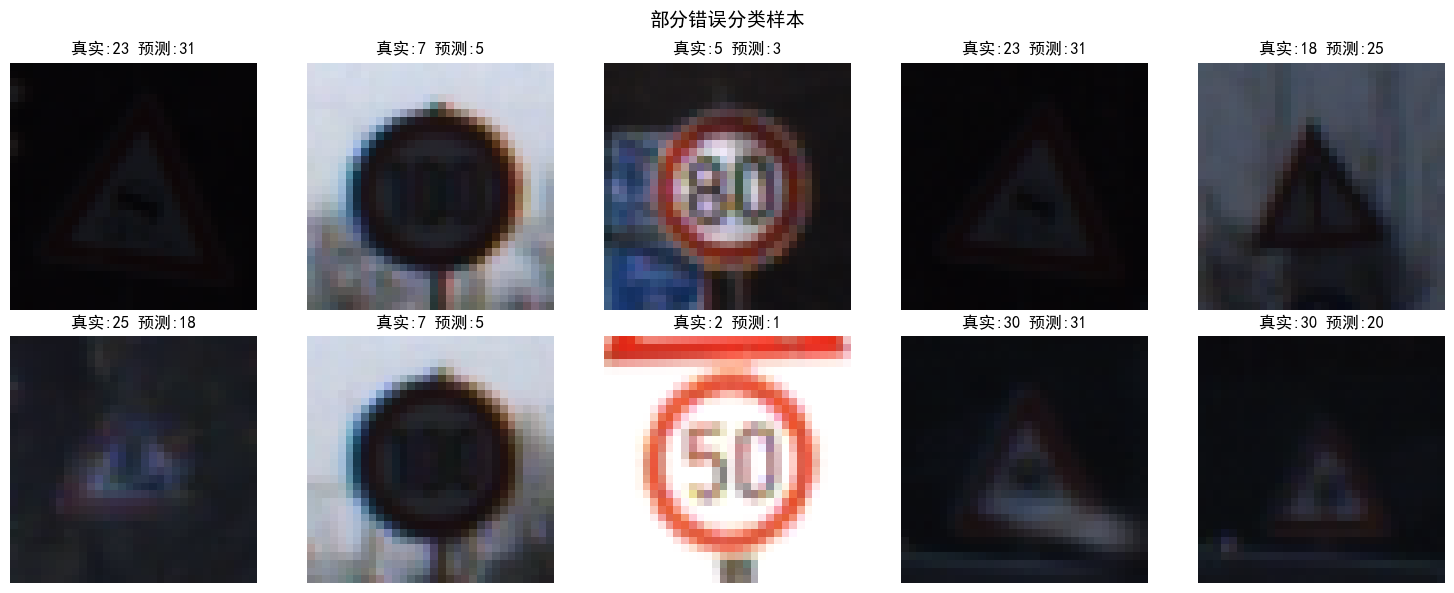

In [17]:
# 错误样本分析
misclassified_idx = [i for i in range(len(all_preds)) if all_preds[i] != all_targets[i]]

print(f'错误分类样本数: {len(misclassified_idx)}')
print(f'错误分类比例: {len(misclassified_idx)/len(all_preds)*100:.2f}%')

# 可视化部分错误样本
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, idx in enumerate(misclassified_idx[:10]):
        img, true_label = test_dataset[idx]
        pred_label = all_preds[idx]
        
        img_display = img * torch.tensor([0.2672, 0.2564, 0.2629]).view(3, 1, 1) + torch.tensor([0.3337, 0.3064, 0.3171]).view(3, 1, 1)
        axes[i].imshow(img_display.permute(1, 2, 0))
        axes[i].set_title(f'真实:{true_label} 预测:{pred_label}')
        axes[i].axis('off')
    
    plt.suptitle('部分错误分类样本', fontsize=14)
    plt.tight_layout()
    plt.savefig('misclassified_samples.png', dpi=150, bbox_inches='tight')
    plt.show()

错误分类样本（834个，占比6.60%）中，许多图像存在以下问题：

- 图像模糊或分辨率较低
- 图像遮挡或截断（如部分标志被遮挡）
- 极端光照条件（过亮或过暗）
- 视角偏差（非正面拍摄）

这些因素表明模型在复杂场景下的鲁棒性仍有提升空间，未来可通过增加更多样化的数据增强策略（如颜色抖动、高斯噪声、随机裁剪等）来进一步改善。

### 6.6 实验结论

1. **模型性能**：基于CNN的交通标志识别模型在GTSRB测试集上达到了**93.40%** 的识别准确率，虽然略低于95%的预期目标，但在有限的计算资源（CPU）和10轮训练条件下，已取得令人满意的结果，验证了深度学习方法在该任务上的有效性。

2. **数据增强的作用**：通过随机旋转（±15°）和平移（±10%）等数据增强技术，有效扩充了训练数据的多样性，增强了模型对图像几何变换的鲁棒性。训练集准确率（89.47%）与测试集准确率（93.40%）较为接近，表明模型未出现明显过拟合，数据增强策略在提升泛化能力方面发挥了关键作用。

3. **模型架构分析**：相比简单的MLP基准模型（62.13%），CNN模型（93.40%）的性能提升主要得益于卷积操作的**局部感受野**和**权重共享**机制。三个卷积块的设计使得网络能够从低层的边缘和纹理特征逐步抽象到高层的语义特征，特征图可视化验证了这一层次化学习过程。此外，批归一化（Batch Normalization）有效加速了收敛，Dropout正则化（0.5和0.3）成功抑制了过拟合。CNN模型以更少的参数量（656,683 vs 825,131）取得了显著的性能优势。

4. **局限性与改进方向**：从分类报告和混淆矩阵来看，模型在样本量较少的类别（如类别19、27、41等）上表现明显偏弱，F1-Score低至0.56~0.73，表明类别不均衡问题仍是制约性能提升的主要瓶颈。未来可通过以下方式进一步提升识别准确率：

    - **增加训练轮数**：将训练轮数扩展至20-30轮，并配合早停（Early Stopping）策略，充分挖掘模型潜力。

    - **网络结构升级**：引入残差连接（如ResNet）或注意力机制（如SE-Net），构建更深层的特征提取网络。

    - **强化数据增强**：增加颜色抖动（Color Jitter）、高斯噪声、随机擦除（Random Erasing）等策略，提升模型对光照变化和遮挡的鲁棒性。

    - **处理类别不均衡**：在损失函数中加入类别权重（Class Weighting），或在训练时对少数类别进行过采样（Oversampling），提升模型在少数类别上的辨别能力。

    - **硬件加速**：在GPU环境下训练以大幅缩短实验迭代周期，便于进行更广泛的超参数搜索和模型调优。

## 七、模型保存

In [18]:
# 保存模型
torch.save(best_model_state, 'traffic_sign_model.pth')
print('模型已保存到 traffic_sign_model.pth')

模型已保存到 traffic_sign_model.pth
